In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cfad
import os
import json
import scipy
    
def load_scaled_lfp_from_dat(file_path):
    # 1. Load metadata to get shape and dtype
    base_name = os.path.splitext(file_path)[0]
    with open(f"{base_name}.json", 'r') as f:
        metadata = json.load(f)
        
    shape = tuple(metadata["shape"])
    dtype = np.dtype(metadata["dtype"])
    
    # 2. Memory-map the flat binary file back into a NumPy array
    lfp_array = np.memmap(file_path, dtype=dtype, mode='r', shape=shape)
    
    return lfp_array, metadata["sampling_rate_hz"]

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_4d_spatiotemporal_lfp(ks_dir, LFP, sampling_rate=1000):
    """
    Plots a 4D spatio-temporal LFP map, sorting channels strictly by physical depth.
    
    Parameters:
    - ks_dir: str, path to the directory containing channel_map.npy and channel_positions.npy
    - LFP: 2D numpy array, shape (num_total_channels, num_samples)
    - sampling_rate: int or float, the sampling frequency in Hz
    """
    
    # 1. Load the Kilosort geometry files
    chan_map = np.load(os.path.join(ks_dir, 'channel_map.npy')).flatten()
    chan_pos = np.load(os.path.join(ks_dir, 'channel_positions.npy'))
    
    num_total_channels, num_samples = LFP.shape
    
    # 2. Initialize coordinate maps indexed by cid with NaNs
    x_map = np.full(num_total_channels, np.nan)
    y_map = np.full(num_total_channels, np.nan)
    
    # 3. Populate spatial maps via acquisition index to cid mapping
    for i, cid in enumerate(chan_map):
        if cid < num_total_channels: 
            x_map[cid] = chan_pos[i, 0]
            y_map[cid] = chan_pos[i, 1]
            
    # 4. Isolate valid channels
    valid_cids = np.where(~np.isnan(x_map))[0]
    
    # 5. Extract valid coordinates and LFP
    x_valid = x_map[valid_cids]
    y_valid = y_map[valid_cids]
    lfp_valid = LFP[valid_cids, :]
    
    # 6. Sort the arrays by depth (Y-coordinate)
    # np.argsort returns the indices that would sort the array
    sort_indices = np.argsort(y_valid)
    
    # 7. Apply the sort indices to align X, Y, and LFP strictly by depth
    x_sorted = x_valid[sort_indices]
    y_sorted = y_valid[sort_indices]
    lfp_sorted = lfp_valid[sort_indices, :]
    
    num_valid = len(valid_cids)
    
    # 8. Generate the temporal axis in seconds
    time_in_seconds = np.arange(num_samples) / sampling_rate
    
    # 9. Vectorized array expansion using the sorted data
    x_coords = np.repeat(x_sorted, num_samples)
    y_coords = np.repeat(y_sorted, num_samples)
    times = np.tile(time_in_seconds, num_valid)
    
    # 10. Flatten the depth-sorted LFP matrix
    voltages = lfp_sorted.flatten()

    # 11. Render the 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(x_coords, times, y_coords, 
                         c=voltages, cmap='coolwarm', marker='o', s=10, alpha=0.6)
    
    ax.set_xlabel('Channel X Position (µm)')
    ax.set_zlabel('Channel Y Position (µm)')
    ax.set_ylabel('Time (s)')
    ax.set_title('Evoked LFP Spatio-Temporal Propagation')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('LFP Amplitude (µV)')
    
    plt.show()
    
    # Optional: return the sorted arrays for further analysis (like CSD)
    return lfp_sorted, x_sorted, y_sorted

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_4d_spatiotemporal_spikes(ks_dir, checker_triggers, sampling_rate=30000, 
                                  window_ms=(-100, 300), time_bin_ms=10, space_bin_um=20):
    """
    Plots a 4D spatio-temporal map of average firing rates aligned to triggers.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory.
    - checker_triggers: 1D array, sample indices of the checkerboard stimuli.
    - sampling_rate: int, spike sampling frequency in Hz (standard is 30000).
    - window_ms: tuple, (start_time, end_time) relative to trigger in milliseconds.
    - time_bin_ms: float, width of the PSTH time bins in milliseconds.
    - space_bin_um: float, width of the spatial bins in micrometers.
    """
    
    # 1. Load the discrete Kilosort data
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert temporal parameters from ms to sample indices
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    aligned_x = []
    aligned_y = []
    aligned_t = []
    
    # 3. Extract and align spikes using binary search for performance
    for trig in checker_triggers:
        # Find the array indices where the spikes enter and exit the time window
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        # Slice the data
        spks_in_win = spike_times[start_idx:end_idx]
        pos_in_win = spike_positions[start_idx:end_idx]
        
        # Convert absolute sample time to relative physical time (seconds)
        rel_time_sec = (spks_in_win - trig) / sampling_rate
        
        # Pool the aligned data
        aligned_t.extend(rel_time_sec)
        aligned_x.extend(pos_in_win[:, 0])
        aligned_y.extend(pos_in_win[:, 1])
        
    aligned_t = np.array(aligned_t)
    aligned_x = np.array(aligned_x)
    aligned_y = np.array(aligned_y)
    
    # 4. Define the 3D Spatio-Temporal Grid (Bins)
    x_bins = np.arange(np.min(aligned_x), np.max(aligned_x) + space_bin_um, space_bin_um)
    y_bins = np.arange(np.min(aligned_y), np.max(aligned_y) + space_bin_um, space_bin_um)
    t_bins = np.arange(window_ms[0]/1000, (window_ms[1] + time_bin_ms)/1000, time_bin_ms/1000)
    
    # 5. Compute the 3D Histogram
    H, edges = np.histogramdd((aligned_x, aligned_y, aligned_t), 
                              bins=(x_bins, y_bins, t_bins))
    
    # 6. Convert spike counts to Firing Rate (Hz)
    num_triggers = len(checker_triggers)
    time_bin_sec = time_bin_ms / 1000
    firing_rate = H / (num_triggers * time_bin_sec)
    
    # 7. Extract the physical center of each bin for plotting
    x_centers = (edges[0][:-1] + edges[0][1:]) / 2
    y_centers = (edges[1][:-1] + edges[1][1:]) / 2
    t_centers = (edges[2][:-1] + edges[2][1:]) / 2
    
    # Create coordinate matrices mapped to the histogram dimensions
    X, Y, T = np.meshgrid(x_centers, y_centers, t_centers, indexing='ij')
    
    # 8. Mask out empty bins to reveal the core response structure
    valid_mask = firing_rate > 0
    plot_x = X[valid_mask]
    plot_y = Y[valid_mask]
    plot_t = T[valid_mask]
    plot_rate = firing_rate[valid_mask]
    
    # 9. Render the 3D Scatter Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Using 'magma' colormap: highly visible for firing rates where baseline is dark
    scatter = ax.scatter(plot_x, plot_y, plot_t, 
                         c=plot_rate, cmap='magma', marker='o', s=15, alpha=0.8)
    
    ax.set_xlabel('Anatomical X (µm)')
    ax.set_ylabel('Anatomical Y (µm)')
    ax.set_zlabel('Time relative to Checkerboard (s)')
    ax.set_title('Evoked Multi-Unit Firing Rate Propagation')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Firing Rate (Hz)')
    
    plt.show()
    
    return firing_rate, edges

In [14]:
FILE_PATH = r'Z:\Saij\Data\Checkerboard\ScMouse8\data\meanLFP\meanLFP.dat'
KS_DIR = cfad.data['Neural']['Renewal']['Concatenated Data']['kilosort4']['Mouse 8']

In [15]:
lfp, fs = load_scaled_lfp_from_dat(FILE_PATH)
chan_pos = np.load(KS_DIR + r"\channel_positions.npy")
chan_map =  np.load(KS_DIR + r"\channel_map.npy")
checker_triggers = np.array(scipy.io.loadmat(cfad.data['Neural']['Renewal']['Triggers']['Checkerboard']['Mouse 8'])["evt"]).flatten()
checker_triggers = checker_triggers[1:]

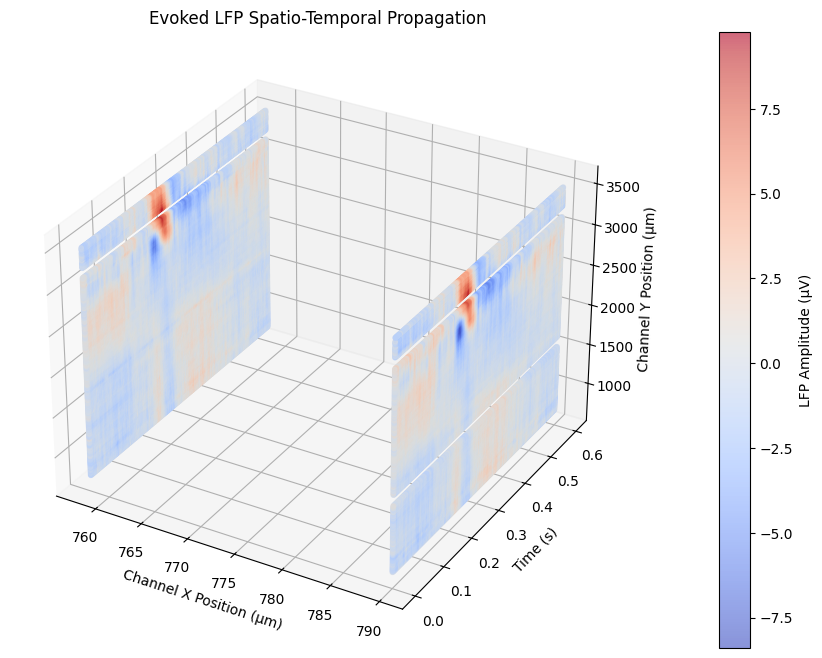

(array([[ 0.01901043, -0.7848737 , -0.69274837, ..., -0.630893  ,
         -0.56080186, -0.56896436],
        [-1.4729508 , -0.8790751 , -0.45026383, ..., -0.64166754,
         -0.1897115 , -0.15810305],
        [-1.3537397 , -0.8893095 , -0.598814  , ..., -0.8584964 ,
         -0.5309384 , -0.45522013],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]], dtype=float32),
 array([790., 758., 758., 790., 790., 758., 758., 790., 758., 790., 758.,
        790., 790., 758., 790., 758., 758., 790., 758., 790., 758., 790.,
        758., 790., 758., 790., 758., 790., 790., 758., 758., 790., 758.,
        790., 758., 790., 758., 790., 790., 758., 758., 790., 758., 790.,
        758., 790., 790., 758., 758., 790., 758., 790., 758., 

In [16]:
plot_4d_spatiotemporal_lfp(KS_DIR, lfp, fs)

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_spatiotemporal_raster(ks_dir, checker_triggers, sampling_rate=30000, window_ms=(-50, 200)):
    """
    Plots a raw 4D spatio-temporal raster of individual spikes aligned to triggers.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory containing spike_times.npy and spike_positions.npy
    - checker_triggers: 1D array, sample indices of the checkerboard stimuli
    - sampling_rate: int, spike sampling frequency in Hz
    - window_ms: tuple, (start_time, end_time) relative to trigger in milliseconds
    """
    
    # 1. Load the discrete Kilosort data
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert temporal window from ms to sample indices
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    # 3. Initialize lists to pool the raw, unbinned spike data
    raw_x = []
    raw_y = []
    raw_t = []
    trial_ids = []
    
    # 4. Extract spikes strictly within the window for each trial
    for trial_idx, trig in enumerate(checker_triggers):
        # Binary search for the window boundaries
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        # Slice the precise spikes and their physical coordinates
        spks_in_win = spike_times[start_idx:end_idx]
        pos_in_win = spike_positions[start_idx:end_idx]
        
        # Calculate continuous relative time in seconds
        rel_time_sec = (spks_in_win - trig) / sampling_rate
        
        # Append to the plotting pools
        raw_t.extend(rel_time_sec)
        raw_x.extend(pos_in_win[:, 0])
        raw_y.extend(pos_in_win[:, 1])
        
        # Track the trial number to use as the 4th color dimension
        trial_ids.extend(np.full(len(spks_in_win), trial_idx))
        
    # Convert lists to NumPy arrays for plotting
    raw_t = np.array(raw_t)
    raw_x = np.array(raw_x)
    raw_y = np.array(raw_y)
    trial_ids = np.array(trial_ids)
    
    # 5. Render the 3D Scatter Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Render every single spike as a tiny point. 
    # alpha is set low so dense clusters visually sum together.
    scatter = ax.scatter(raw_x, raw_y, raw_t, 
                         c=trial_ids, cmap='viridis', marker='.', s=5, alpha=0.3)
    
    ax.set_xlabel('Anatomical X (µm)')
    ax.set_ylabel('Anatomical Y (µm)')
    ax.set_zlabel('Time relative to Checkerboard (s)')
    ax.set_title('Raw Spatio-Temporal Spike Raster')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Trial Number')
    
    plt.show()

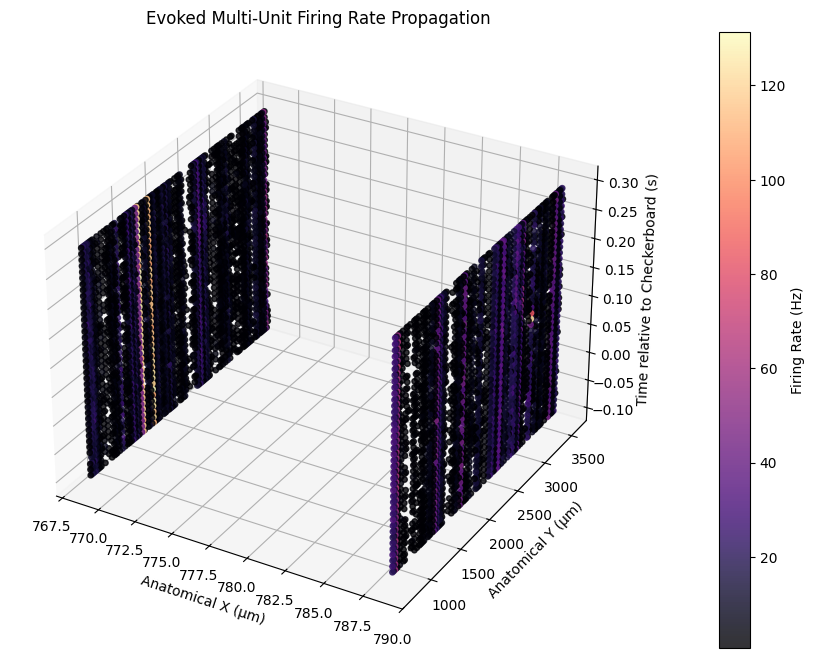

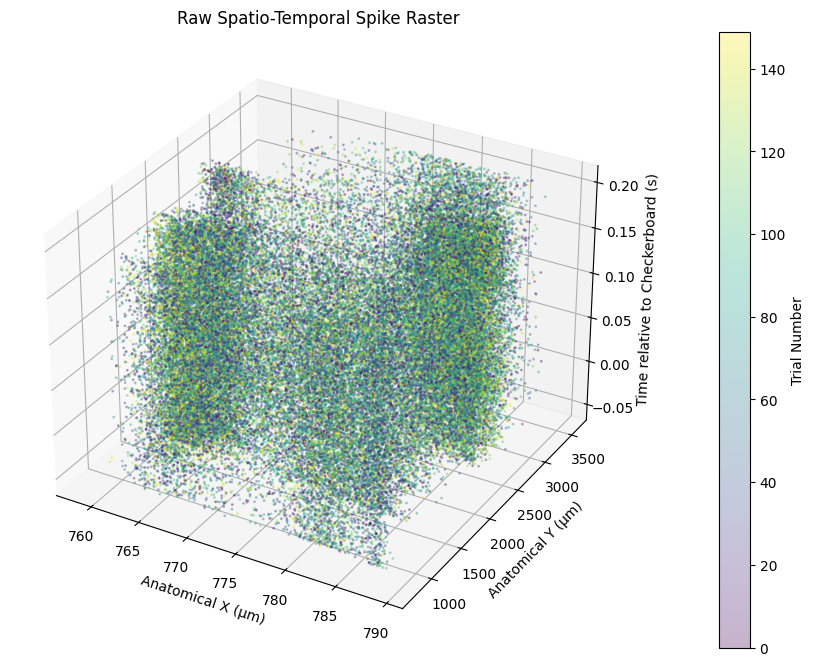

In [44]:
plot_4d_spatiotemporal_spikes(KS_DIR, checker_triggers)
plot_raw_spatiotemporal_raster(KS_DIR, checker_triggers)

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_4d_density_raster(ks_dir, checker_triggers, sampling_rate=30000, 
                           window_ms=(-100, 500), max_kde_points=2000):
    """
    Plots a 4D raw raster plot where points are colored and sized by local density.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory containing spike_times.npy and spike_positions.npy
    - checker_triggers: 1D array, sample indices of the checkerboard stimuli
    - sampling_rate: int, spike sampling frequency in Hz
    - window_ms: tuple, (start_time, end_time) relative to trigger in milliseconds
    - max_kde_points: int, maximum number of random points used to estimate the density function.
                       Increase for more precision, decrease for faster performance.
    """
    
    # 1. Load the discrete Kilosort data
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert temporal window from ms to sample indices
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    # 3. Initialize lists to pool the raw, unbinned spike data across trials
    raw_x = []
    raw_y = []
    raw_t = []
    
    print(f"Extracting spikes from {len(checker_triggers)} trials...")
    
    # 4. Extract spikes strictly within the window for each trial
    for trig in checker_triggers:
        # Binary search for the window boundaries
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        # Slice the precise spikes and their physical coordinates
        spks_in_win = spike_times[start_idx:end_idx]
        pos_in_win = spike_positions[start_idx:end_idx]
        
        # Calculate continuous relative time in seconds
        rel_time_sec = (spks_in_win - trig) / sampling_rate
        
        # Append to the plotting pools
        raw_t.extend(rel_time_sec)
        raw_x.extend(pos_in_win[:, 0])
        raw_y.extend(pos_in_win[:, 1])
        
    # Convert lists to NumPy arrays
    raw_t = np.array(raw_t)
    raw_x = np.array(raw_x)
    raw_y = np.array(raw_y)
    num_spikes = len(raw_t)
    
    print(f"Total spikes in window: {num_spikes}")
    
    if num_spikes == 0:
        print("No spikes found in the specified window. Plotting cancelled.")
        return

    # 5. Calculate Gaussian Kernel Density Estimate (KDE)
    # Combine (X, Y, T) into a (3, N) matrix as required by scipy.stats.gaussian_kde
    data = np.vstack([raw_x, raw_y, raw_t])
    
    print("Calculating 3D Density (KDE)... This may take a moment.")
    
    # Optimize calculation performance by downsampling the estimation subset
    if num_spikes > max_kde_points:
        idx = np.random.choice(num_spikes, max_kde_points, replace=False)
        kde_subset = data[:, idx]
        # Train the kernel function on the subset
        kernel = gaussian_kde(kde_subset)
    else:
        # Train the kernel function on all data
        kernel = gaussian_kde(data)
    
    # Evaluate the trained kernel at the coordinate of *every* spike
    density_scores = kernel(data)
    
    # 6. Normalize density scores to use as colormap/size metric
    density_normalized = (density_scores - np.min(density_scores)) / np.ptp(density_scores)

    # 7. Render the 3D Scatter Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Dynamically scale marker size based on normalized density (min size 3, max size 30)
    point_sizes = 3 + (27 * density_normalized)
    
    # Map normalized density to color. Use low alpha to preserve alpha-compositing effect
    # Colormap 'magma' is excellent as isolated points (low density) are dark/purple
    # and dense clusters (high density) are bright yellow/white.
    scatter = ax.scatter(raw_x, raw_y, raw_t, 
                         c=density_normalized, cmap='magma', marker='.', s=point_sizes, alpha=0.3)
    
    ax.set_xlabel('Anatomical X (µm)')
    ax.set_ylabel('Anatomical Y (µm)')
    ax.set_zlabel('Time relative to Checkerboard (s)')
    ax.set_title('Raw Spatio-Temporal Raster: Clustered Activity Highlighted by Density')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Normalized Local Density')
    
    plt.show()

Extracting spikes from 150 trials...
Total spikes in window: 140921
Calculating 3D Density (KDE)... This may take a moment.


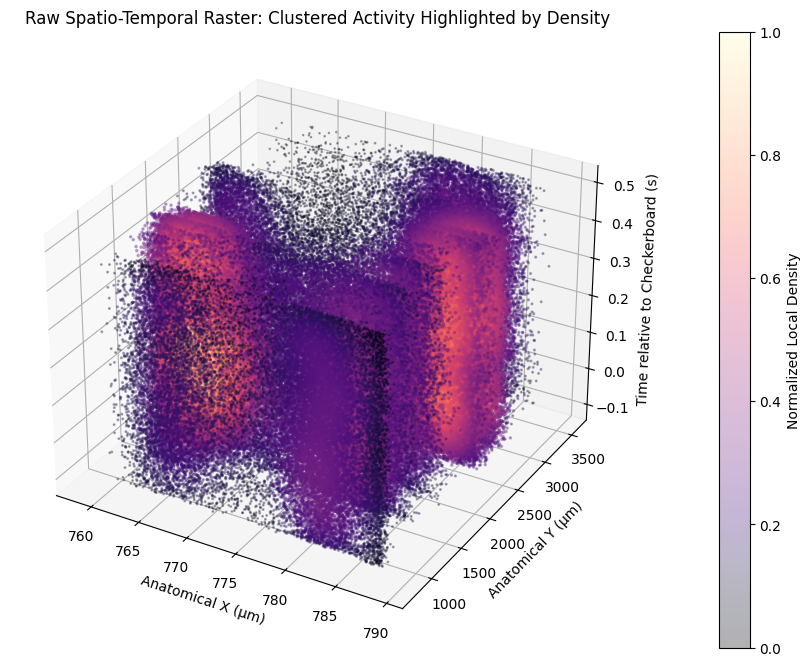

In [48]:
plot_4d_density_raster(KS_DIR, checker_triggers)

In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_baseline_normalized_raster(ks_dir, checker_triggers, sampling_rate=30000, 
                                    window_ms=(-100, 500), max_kde_points=2000):
    """
    Plots a 4D raster where spike density is Z-score normalized to the pre-stimulus baseline.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory containing spike_times.npy and spike_positions.npy
    - checker_triggers: 1D array, sample indices of the checkerboard stimuli
    - sampling_rate: int, spike sampling frequency in Hz
    - window_ms: tuple, (start_time, end_time) relative to trigger in milliseconds. Must start < 0.
    - max_kde_points: int, max points for KDE training to optimize performance.
    """
    
    if window_ms[0] >= 0:
        raise ValueError("The window must start before 0 (e.g., -50) to establish a baseline.")

    # 1. Load the discrete Kilosort arrays
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert temporal window from ms to sample indices
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    raw_x = []
    raw_y = []
    raw_t = []
    
    # 3. Extract unbinned spikes across all trials
    for trig in checker_triggers:
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        spks_in_win = spike_times[start_idx:end_idx]
        pos_in_win = spike_positions[start_idx:end_idx]
        
        rel_time_sec = (spks_in_win - trig) / sampling_rate
        
        raw_t.extend(rel_time_sec)
        raw_x.extend(pos_in_win[:, 0])
        raw_y.extend(pos_in_win[:, 1])
        
    raw_t = np.array(raw_t)
    raw_x = np.array(raw_x)
    raw_y = np.array(raw_y)
    num_spikes = len(raw_t)
    
    if num_spikes == 0:
        print("No spikes found in the specified window.")
        return

    # 4. Construct the 3D coordinate matrix for KDE
    data = np.vstack([raw_x, raw_y, raw_t])
    
    # 5. Train the 3D Gaussian KDE (using a downsampled subset if necessary for speed)
    if num_spikes > max_kde_points:
        idx = np.random.choice(num_spikes, max_kde_points, replace=False)
        kde_subset = data[:, idx]
        kernel = gaussian_kde(kde_subset)
    else:
        kernel = gaussian_kde(data)
    
    # 6. Evaluate the absolute density at every single spike coordinate
    absolute_density = kernel(data)
    
    # 7. Baseline Normalization (Z-scoring)
    # Isolate the density scores of spikes that occurred before the stimulus (t < 0)
    baseline_mask = raw_t < 0
    
    if not np.any(baseline_mask):
        print("Warning: No spikes found in the pre-stimulus baseline period.")
        z_density = absolute_density  # Fallback if baseline is empty
    else:
        # Calculate the baseline statistics
        mu_base = np.mean(absolute_density[baseline_mask])
        sigma_base = np.std(absolute_density[baseline_mask])
        
        # Prevent division by zero if baseline variance is flat
        if sigma_base == 0:
            sigma_base = 1e-6 
            
        # Compute the Z-score for all spikes (both baseline and evoked)
        z_density = (absolute_density - mu_base) / sigma_base

    # 8. Render the 3D Scatter Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Dynamically scale marker sizes. 
    # Use np.clip to ensure suppressed spikes (negative Z) don't get negative sizes.
    # Spikes > 0 Z-score grow up to 25 pts, spikes < 0 Z-score shrink to 2 pts.
    positive_z_clipped = np.clip(z_density, 0, None)
    point_sizes = 2 + (23 * (positive_z_clipped / (np.max(positive_z_clipped) + 1e-6)))
    
    # A diverging colormap (coolwarm) maps negative values to blue and positive to red.
    # vcenter=0 ensures that exactly 0 Z-score (baseline mean) is perfectly neutral.
    import matplotlib.colors as mcolors
    norm = mcolors.TwoSlopeNorm(vmin=np.min(z_density), vcenter=0, vmax=np.max(z_density))
    
    scatter = ax.scatter(raw_x, raw_y, raw_t, 
                         c=z_density, cmap='coolwarm', norm=norm, marker='.', s=point_sizes, alpha=0.4)
    
    ax.set_xlabel('Anatomical X (µm)')
    ax.set_ylabel('Anatomical Y (µm)')
    ax.set_zlabel('Time relative to Checkerboard (s)')
    ax.set_title('Evoked Spatio-Temporal Spiking (Z-Scored to Pre-Stimulus)')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Density Z-Score (vs Baseline)')
    
    plt.show()

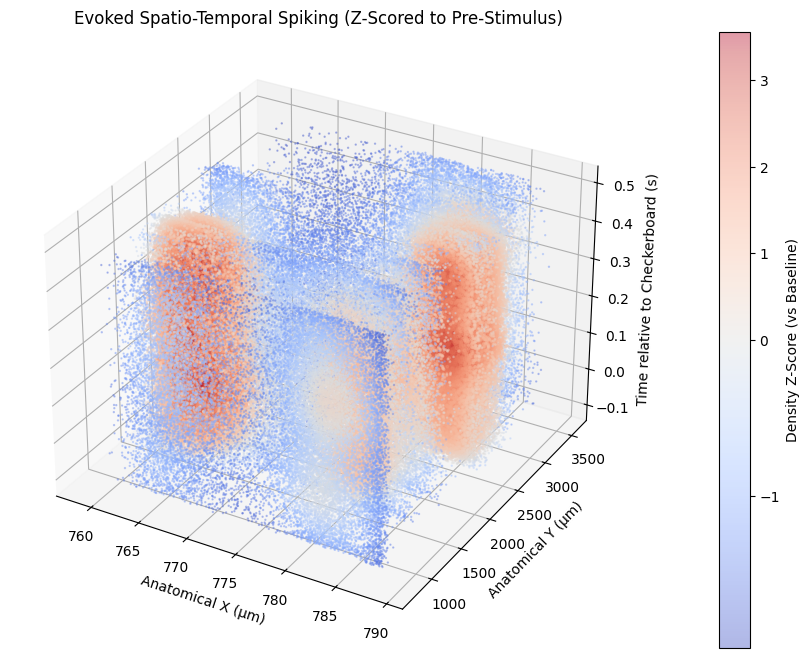

In [52]:
plot_baseline_normalized_raster(KS_DIR, checker_triggers)

In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_4d_mua_binned(ks_dir, checker_triggers, sampling_rate=30000, 
                       window_ms=(-50, 200), time_bin_ms=2, space_bin_um=7):
    """
    Plots a 4D representation of Multi-Unit Activity (MUA) by binning spikes 
    in space and time to calculate average firing rates.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory
    - checker_triggers: 1D array, sample indices of the checkerboard stimuli
    - sampling_rate: int, spike sampling frequency in Hz
    - window_ms: tuple, (start_time, end_time) relative to trigger in ms
    - time_bin_ms: float, temporal bin width in ms
    - space_bin_um: float, spatial bin width in micrometers
    """
    
    # 1. Load Kilosort arrays
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert boundaries
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    raw_x = []
    raw_y = []
    raw_t = []
    
    # 3. Extract unbinned spikes across all trials for the specific window
    for trig in checker_triggers:
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        spks_in_win = spike_times[start_idx:end_idx]
        pos_in_win = spike_positions[start_idx:end_idx]
        
        rel_time_sec = (spks_in_win - trig) / sampling_rate
        
        raw_t.extend(rel_time_sec)
        raw_x.extend(pos_in_win[:, 0])
        raw_y.extend(pos_in_win[:, 1])
        
    raw_t = np.array(raw_t)
    raw_x = np.array(raw_x)
    raw_y = np.array(raw_y)
    
    if len(raw_t) == 0:
        print("No spikes found in the specified window.")
        return

    # 4. Define the 3D grid boundaries (Edges)
    x_edges = np.arange(np.min(raw_x), np.max(raw_x) + space_bin_um, space_bin_um)
    y_edges = np.arange(np.min(raw_y), np.max(raw_y) + space_bin_um, space_bin_um)
    t_edges = np.arange(window_ms[0]/1000, (window_ms[1] + time_bin_ms)/1000, time_bin_ms/1000)
    
    # 5. Compute the 3D Histogram (Spike Counts per Voxel)
    H, edges = np.histogramdd((raw_x, raw_y, raw_t), bins=(x_edges, y_edges, t_edges))
    
    # 6. Convert Raw Counts to Average Firing Rate (Hz)
    num_trials = len(checker_triggers)
    time_bin_sec = time_bin_ms / 1000
    firing_rate_hz = H / (num_trials * time_bin_sec)
    
    # 7. Extract the exact center of each bin to use as plotting coordinates
    x_centers = (edges[0][:-1] + edges[0][1:]) / 2
    y_centers = (edges[1][:-1] + edges[1][1:]) / 2
    t_centers = (edges[2][:-1] + edges[2][1:]) / 2
    
    # Generate 3D coordinate matrices
    X, Y, T = np.meshgrid(x_centers, y_centers, t_centers, indexing='ij')
    
    # 8. Filter out empty or low-firing bins to reveal the main "blob"
    # Setting a threshold > 0 completely removes empty space. 
    # You can increase this (e.g., > 5 Hz) to isolate only the dense MUA burst.
    mask = firing_rate_hz > 0
    
    plot_x = X[mask]
    plot_y = Y[mask]
    plot_t = T[mask]
    plot_fr = firing_rate_hz[mask]
    
    # 9. Render the 3D Voxel Scatter Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Size the markers by firing rate to make the dense cluster physically larger in the plot
    # Marker 's' (square) simulates a 3D voxel visually better than a circle.
    min_size = 10
    scaling_factor = 100 / np.max(plot_fr)
    sizes = min_size + (plot_fr * scaling_factor)
    
    scatter = ax.scatter(plot_x, plot_y, plot_t, 
                         c=plot_fr, cmap='turbo', marker='s', s=sizes, alpha=0.7)
    
    ax.set_xlabel('Anatomical X (µm)')
    ax.set_ylabel('Anatomical Y (µm)')
    ax.set_zlabel('Time relative to Checkerboard (s)')
    ax.set_title(f'Spatio-Temporal MUA (Bins: {space_bin_um}µm, {time_bin_ms}ms)')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Average Firing Rate (Hz)')
    
    plt.show()
    
    return firing_rate_hz, edges

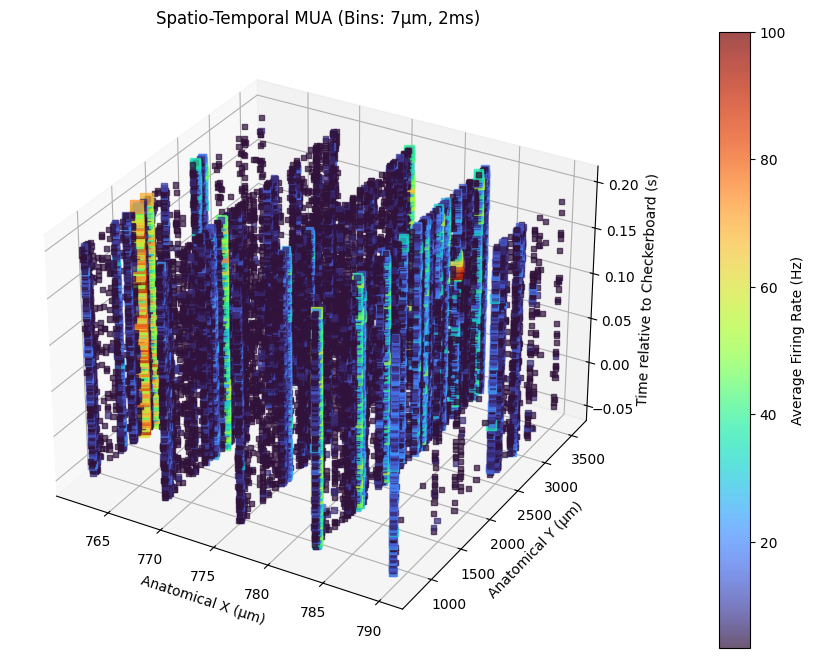

(array([[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           3.33333333,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]],
 
        [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 3.33333333,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.       

In [60]:
plot_4d_mua_binned(KS_DIR, checker_triggers)

In [67]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def plot_4d_mua_smoothed(ks_dir, checker_triggers, sampling_rate=30000, 
                         window_ms=(-50, 200), time_bin_ms=5, space_bin_um=10,
                         sigma_smooth=(0.5, 0.5, 0.5), threshold_hz=10):
    """
    Plots a smooth, continuous 4D representation of Multi-Unit Activity (MUA).
    
    Parameters:
    - ks_dir: str, path to Kilosort directory
    - checker_triggers: 1D array, sample indices of the stimuli
    - sampling_rate: int, spike sampling frequency in Hz
    - window_ms: tuple, (start, end) relative to trigger in ms
    - time_bin_ms: float, temporal bin width in ms
    - space_bin_um: float, spatial bin width in micrometers
    - sigma_smooth: tuple, standard deviation for Gaussian kernel in (X, Y, T) dimensions
    - threshold_hz: float, minimum firing rate to plot, isolating the core blob
    """
    
    # 1. Load Kilosort arrays
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert boundaries to sample indices
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    raw_x, raw_y, raw_t = [], [], []
    
    # 3. Fast extraction of unbinned spikes
    for trig in checker_triggers:
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        spks_in_win = spike_times[start_idx:end_idx]
        pos_in_win = spike_positions[start_idx:end_idx]
        
        raw_t.extend((spks_in_win - trig) / sampling_rate)
        raw_x.extend(pos_in_win[:, 0])
        raw_y.extend(pos_in_win[:, 1])
        
    raw_t = np.array(raw_t)
    raw_x = np.array(raw_x)
    raw_y = np.array(raw_y)
    
    if len(raw_t) == 0:
        print("No spikes found in the specified window.")
        return

    # 4. Construct the 3D grid
    x_edges = np.arange(np.min(raw_x), np.max(raw_x) + space_bin_um, space_bin_um)
    y_edges = np.arange(np.min(raw_y), np.max(raw_y) + space_bin_um, space_bin_um)
    t_edges = np.arange(window_ms[0]/1000, (window_ms[1] + time_bin_ms)/1000, time_bin_ms/1000)
    
    # 5. Compute the raw 3D Histogram
    H, edges = np.histogramdd((raw_x, raw_y, raw_t), bins=(x_edges, y_edges, t_edges))
    
    # 6. Apply 3D Gaussian Smoothing
    H_smoothed = gaussian_filter(H, sigma=sigma_smooth)
    
    # 7. Convert Smoothed Counts to Average Firing Rate (Hz)
    num_trials = len(checker_triggers)
    time_bin_sec = time_bin_ms / 1000
    firing_rate_hz = H_smoothed / (num_trials * time_bin_sec)
    
    # 8. Extract voxel centers for plotting
    x_centers = (edges[0][:-1] + edges[0][1:]) / 2
    y_centers = (edges[1][:-1] + edges[1][1:]) / 2
    t_centers = (edges[2][:-1] + edges[2][1:]) / 2
    
    X, Y, T = np.meshgrid(x_centers, y_centers, t_centers, indexing='ij')
    
    # 9. Apply threshold to isolate the continuous high-firing blob
    mask = firing_rate_hz > threshold_hz
    
    plot_x = X[mask]
    plot_y = Y[mask]
    plot_t = T[mask]
    plot_fr = firing_rate_hz[mask]
    
    # 10. Render the Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Use spherical markers and alpha compositing to render the smooth cloud
    scatter = ax.scatter(plot_x, plot_y, plot_t, 
                         c=plot_fr, cmap='turbo', marker='o', s=40, alpha=0.3)
    
    ax.set_xlabel('Anatomical X (µm)')
    ax.set_ylabel('Anatomical Y (µm)')
    ax.set_zlabel('Time relative to Checkerboard (s)')
    ax.set_title('Smoothed Volumetric MUA Dynamics')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Average Firing Rate (Hz)')
    
    plt.show()
    
    return firing_rate_hz, edges

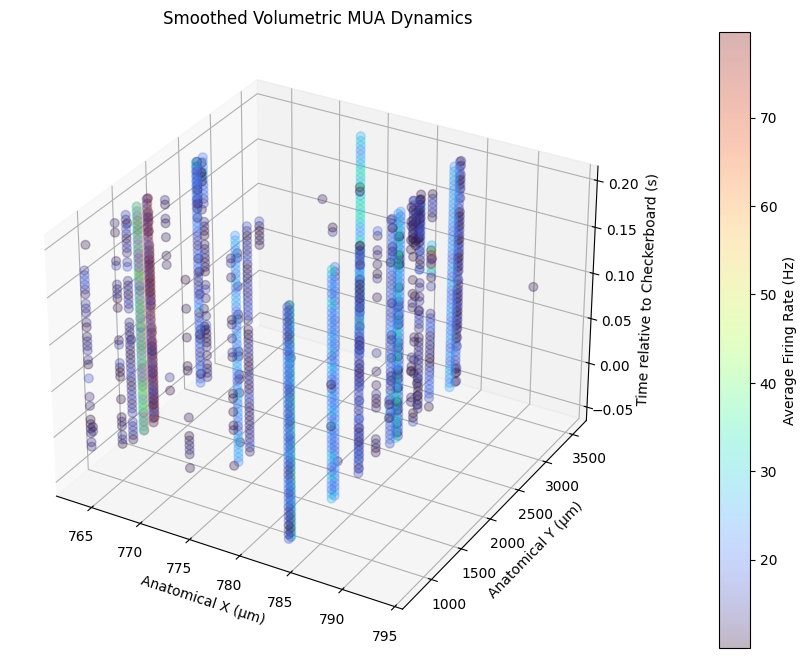

(array([[[4.65638923e-02, 1.09677477e-01, 1.45814429e-01, ...,
          3.43175643e-01, 9.89017334e-01, 1.09597685e+00],
         [3.33895008e-01, 9.13767277e-01, 3.35434125e-01, ...,
          1.08154577e+00, 3.87059060e-01, 3.71867832e-01],
         [1.27432582e+00, 1.84690334e+00, 2.14791713e+00, ...,
          2.46681864e+00, 2.04635734e+00, 1.50599994e+00],
         ...,
         [9.68313421e-03, 4.25314877e-02, 3.31249404e-02, ...,
          1.47549166e-01, 6.76046806e-02, 7.74292081e-02],
         [6.13193684e-04, 2.58433438e-03, 1.30170684e-02, ...,
          1.13039802e-01, 1.26384904e-01, 2.12504889e-01],
         [4.28938011e-05, 1.35941272e-02, 1.00017560e-01, ...,
          1.36906474e-02, 1.68472533e-02, 2.87489557e-02]],
 
        [[2.54441301e+00, 1.76217723e+00, 2.21034602e+00, ...,
          3.17510501e+00, 2.42109132e+00, 2.60570282e+00],
         [2.10040642e+00, 8.83252829e-01, 1.17479980e+00, ...,
          2.21645679e+00, 1.27751104e+00, 2.13403786e+00],
       

In [68]:
plot_4d_mua_smoothed(KS_DIR, checker_triggers)

In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def plot_interactive_2d_mua(ks_dir, sampling_rate=30000, time_bin_ms=10, 
                            depth_bin_um=20, view_window_sec=10):
    """
    Plots a 2D interactive MUA heatmap (Depth vs. Time) with a horizontal scrollbar.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory containing spike arrays
    - sampling_rate: int, spike sampling frequency in Hz
    - time_bin_ms: float, temporal bin width in milliseconds
    - depth_bin_um: float, spatial bin width for the Y-axis (depth) in micrometers
    - view_window_sec: float, the amount of time (in seconds) visible on screen at once
    """
    
    # 1. Load the discrete Kilosort data
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Extract strictly Depth (Y) and Continuous Time (Seconds)
    spike_depths = spike_positions[:, 1]
    spike_times_sec = spike_times / sampling_rate
    
    # 3. Define the 2D Grid Boundaries
    max_time = spike_times_sec[-1]
    time_bins = np.arange(0, max_time + (time_bin_ms/1000), time_bin_ms/1000)
    
    min_depth = np.min(spike_depths)
    max_depth = np.max(spike_depths)
    depth_bins = np.arange(min_depth, max_depth + depth_bin_um, depth_bin_um)
    
    # 4. Compute the 2D Histogram (Spike Counts per Bin)
    # H shape will be (len(depth_bins)-1, len(time_bins)-1)
    H, yedges, xedges = np.histogram2d(spike_depths, spike_times_sec, 
                                       bins=[depth_bins, time_bins])
    
    # 5. Convert Raw Counts to Firing Rate (Hz)
    # Since this is continuous, we divide by the time bin width in seconds.
    firing_rate = H / (time_bin_ms / 1000)
    
    # 6. Initialize the Figure and Axes
    fig, ax = plt.subplots(figsize=(14, 7))
    plt.subplots_adjust(bottom=0.2) # Reserve space at the bottom for the slider
    
    # 7. Render the Heatmap (pcolormesh is highly optimized for large grids)
    # Cap the maximum color value at the 99th percentile to prevent outliers from washing out the colormap
    vmax_clip = np.percentile(firing_rate, 99)
    mesh = ax.pcolormesh(xedges, yedges, firing_rate, cmap='magma', 
                         shading='auto', vmin=0, vmax=vmax_clip)
    
    ax.set_ylabel('Anatomical Depth (µm)')
    ax.set_xlabel('Continuous Time (s)')
    ax.set_title(f'Continuous Lamination MUA (Bins: {depth_bin_um}µm, {time_bin_ms}ms)')
    
    # 8. Set the initial view window
    ax.set_xlim(0, view_window_sec)
    
    # 9. Configure the Interactive Slider
    axcolor = 'lightgoldenrodyellow'
    axpos = plt.axes([0.125, 0.05, 0.775, 0.03], facecolor=axcolor)
    
    # The slider controls the START time of the window
    t_slider = Slider(axpos, 'Scroll Time (s)', valmin=0, 
                      valmax=max_time - view_window_sec, valinit=0, valstep=0.5)
    
    # 10. Define the Update Function
    def update(val):
        pos = t_slider.val
        # Shift the X-axis limits based on the slider position
        ax.set_xlim(pos, pos + view_window_sec)
        fig.canvas.draw_idle() # Redraw the figure efficiently
        
    # Bind the update function to the slider
    t_slider.on_changed(update)
    
    # 11. Add Colorbar
    cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label('Average Firing Rate (Hz)')
    
    plt.show()
    
    # Return the slider object. If not returned, Python's garbage collector 
    # will delete the widget and it will not respond to clicks.
    return t_slider

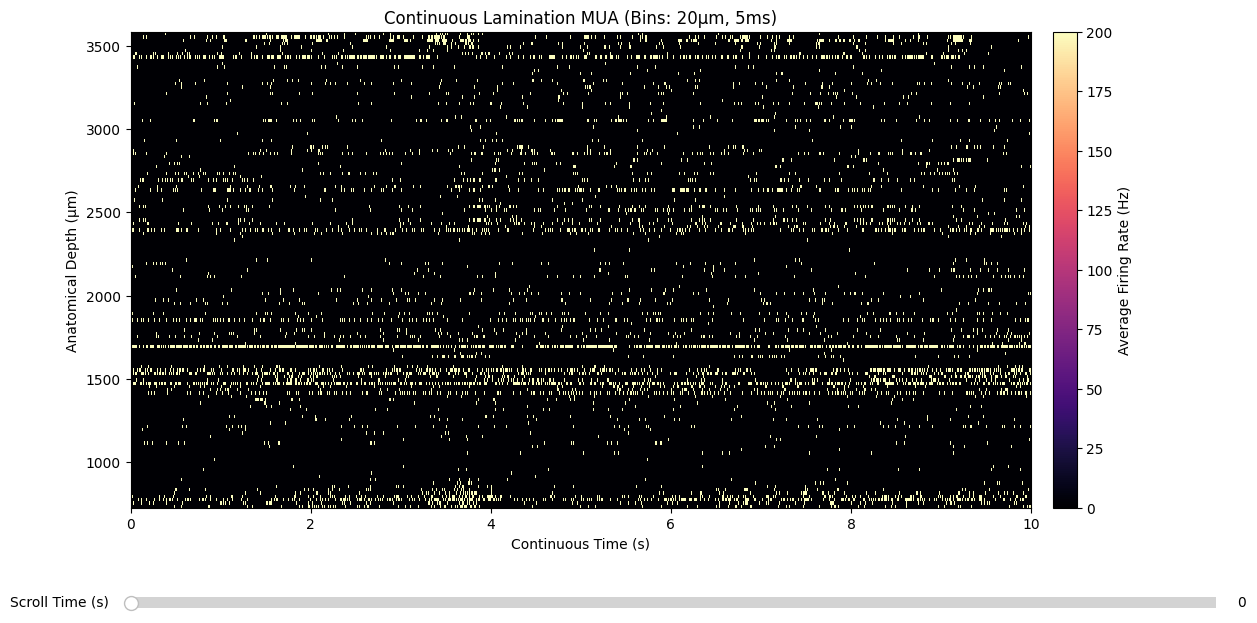

In [72]:
plot_interactive_2d_mua(KS_DIR, 30000, 5, 20, 10)

In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_2d_mua_psth(ks_dir, checker_triggers, sampling_rate=30000, 
                     window_ms=(-200, 800), time_bin_ms=5, depth_bin_um=20):
    """
    Plots a 2D Multi-Unit Activity (MUA) heatmap (Depth vs. Relative Time) 
    averaged across all trigger events.
    
    Parameters:
    - ks_dir: str, path to Kilosort directory
    - checker_triggers: 1D array, sample indices of the stimuli
    - sampling_rate: int, spike sampling frequency in Hz
    - window_ms: tuple, (start_time, end_time) relative to trigger in milliseconds
    - time_bin_ms: float, temporal bin width in milliseconds
    - depth_bin_um: float, spatial bin width for the Y-axis (depth) in micrometers
    """
    
    # 1. Load the discrete Kilosort data
    spike_times = np.load(os.path.join(ks_dir, 'spike_times.npy')).flatten()
    spike_positions = np.load(os.path.join(ks_dir, 'spike_positions.npy'))
    
    # 2. Convert the window from milliseconds to sample indices
    win_start_samp = int((window_ms[0] / 1000) * sampling_rate)
    win_end_samp = int((window_ms[1] / 1000) * sampling_rate)
    
    # 3. Initialize lists for the peri-stimulus spikes
    aligned_depths = []
    aligned_times_sec = []
    
    num_triggers = len(checker_triggers)
    
    # 4. Extract and align spikes for every trial
    for trig in checker_triggers:
        # Binary search for fast indexing
        start_idx = np.searchsorted(spike_times, trig + win_start_samp)
        end_idx = np.searchsorted(spike_times, trig + win_end_samp)
        
        spks_in_win = spike_times[start_idx:end_idx]
        depths_in_win = spike_positions[start_idx:end_idx, 1] # Extract only Y (depth)
        
        # Calculate continuous time relative to the trigger in seconds
        rel_time_sec = (spks_in_win - trig) / sampling_rate
        
        aligned_times_sec.extend(rel_time_sec)
        aligned_depths.extend(depths_in_win)
        
    aligned_times_sec = np.array(aligned_times_sec)
    aligned_depths = np.array(aligned_depths)
    
    if len(aligned_times_sec) == 0:
        print("No spikes found in the specified windows.")
        return

    # 5. Define the 2D Grid Boundaries (Edges)
    time_edges = np.arange(window_ms[0]/1000, (window_ms[1] + time_bin_ms)/1000, time_bin_ms/1000)
    
    min_depth = np.min(aligned_depths)
    max_depth = np.max(aligned_depths)
    depth_edges = np.arange(min_depth, max_depth + depth_bin_um, depth_bin_um)
    
    # 6. Compute the 2D Histogram (Spike Counts per Bin)
    H, yedges, xedges = np.histogram2d(aligned_depths, aligned_times_sec, 
                                       bins=[depth_edges, time_edges])
    
    # 7. Convert Raw Counts to Trial-Averaged Firing Rate (Hz)
    time_bin_sec = time_bin_ms / 1000
    firing_rate_hz = H / (num_triggers * time_bin_sec)
    
    # 8. Initialize the Figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 9. Render the Heatmap
    # pcolormesh draws the exact rectangular bins created by the histogram
    vmax_clip = np.percentile(firing_rate_hz, 99.5) # Clip extreme outliers for better contrast
    mesh = ax.pcolormesh(xedges, yedges, firing_rate_hz, cmap='magma', 
                         shading='auto', vmin=0, vmax=vmax_clip)
    
    # 10. Draw a vertical line precisely at the stimulus onset (t=0)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
    
    ax.set_ylabel('Anatomical Depth (µm)')
    ax.set_xlabel('Time relative to Checkerboard (s)')
    ax.set_title(f'Trial-Averaged Spatio-Temporal MUA ({num_triggers} Trials)')
    
    # 11. Add Colorbar
    cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label('Average Firing Rate (Hz)')
    
    plt.show()
    
    return firing_rate_hz, yedges, xedges

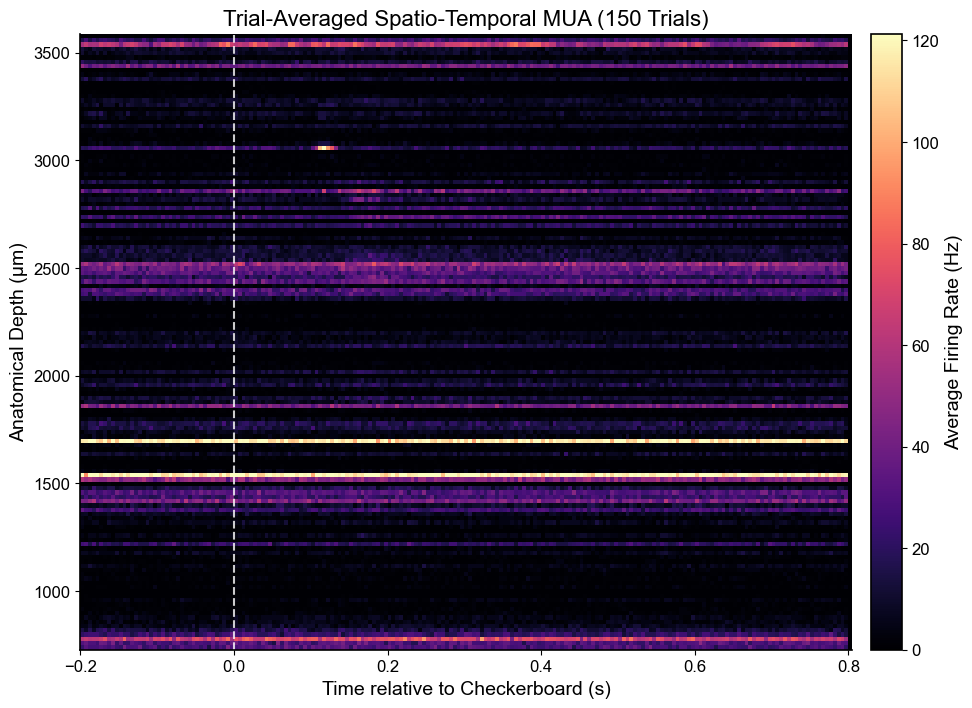

(array([[22.66666667, 32.        , 26.66666667, ..., 32.        ,
         20.        ,  0.        ],
        [30.66666667, 36.        , 29.33333333, ..., 30.66666667,
         29.33333333,  0.        ],
        [61.33333333, 65.33333333, 61.33333333, ..., 66.66666667,
         53.33333333,  0.        ],
        ...,
        [56.        , 64.        , 56.        , ..., 52.        ,
         61.33333333,  0.        ],
        [16.        , 25.33333333, 14.66666667, ..., 21.33333333,
         17.33333333,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  1.33333333,
          0.        ,  0.        ]], shape=(143, 201)),
 array([ 728.1831665,  748.1831665,  768.1831665,  788.1831665,
         808.1831665,  828.1831665,  848.1831665,  868.1831665,
         888.1831665,  908.1831665,  928.1831665,  948.1831665,
         968.1831665,  988.1831665, 1008.1831665, 1028.1831665,
        1048.1831665, 1068.1831665, 1088.1831665, 1108.1831665,
        1128.1831665, 1148.1831665,

In [83]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'pdf.fonttype': 42,  # Ensures fonts are editable in Adobe Illustrator
    'ps.fonttype': 42,
    'axes.spines.top': False,   # "Despining" for a cleaner look
    'axes.spines.right': False
})

plot_2d_mua_psth(KS_DIR, checker_triggers)